In [ ]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

import plotly.graph_objects as go
from umap import UMAP
from typing import Dict, List
import plotly.io as pio



## Functions

In [3]:
def impute_normal_down_shift_distribution(unimputerd_dataframe:pd.DataFrame ,column_wise=True, width=0.3, downshift=1.8, seed=2):
    """ 
    Performs imputation across a matrix columnswise
    https://rdrr.io/github/jdreyf/jdcbioinfo/man/impute_normal.html#google_vignette
    :width: Scale factor for the standard deviation of imputed distribution relative to the sample standard deviation.
    :downshift: Down-shifted the mean of imputed distribution from the sample mean, in units of sample standard deviation.
    :seed: Random seed
    
    """
    print('The size of the data Frame before imputation')
    print(unimputerd_dataframe.shape)
    unimputerd_df = unimputerd_dataframe.iloc[:,:]
    unimputerd_matrix = unimputerd_df.replace({pd.NA: np.nan}, inplace=True) #Added to modify pandas's NAN values into  numpy NAN values
    unimputerd_matrix = unimputerd_df.to_numpy()
    columns_names = unimputerd_df.columns
    rownames = unimputerd_df.index
    unimputerd_matrix[~np.isfinite(unimputerd_matrix)] = None
    main_mean = np.nanmean(unimputerd_matrix)
    main_std = np.nanstd(unimputerd_matrix)
    np.random.seed(seed = seed)
    def impute_normal_per_vector(temp:np.ndarray,width=width, downshift=downshift):
        """ Performs imputation for a single vector """
        if column_wise:
            temp_sd = np.nanstd(temp)
            temp_mean = np.nanmean(temp)
        else:
            # over all matrix
            temp_sd = main_std
            temp_mean = main_mean

        shrinked_sd = width * temp_sd
        downshifted_mean = temp_mean - (downshift * temp_sd) 
        n_missing = np.count_nonzero(np.isnan(temp))
        temp[np.isnan(temp)] = np.random.normal(loc=downshifted_mean, scale=shrinked_sd, size=n_missing)
        if n_missing > 0:
            print 
        return temp
    final_matrix = np.apply_along_axis(impute_normal_per_vector, 0, unimputerd_matrix)
    final_df = pd.DataFrame(final_matrix)
    final_df.index = rownames
    final_df.columns = columns_names
    
    return final_df

def load_txt_folder(folder_path):
    folder = Path(folder_path)
    txt_dict = {}

    for file in folder.glob("*.txt"):   # only .txt files
        key = file.stem                 # filename without extension
        with open(file, "r") as f:
            lines = [line.strip() for line in f if line.strip() != ""]
        txt_dict[key] = lines

    return txt_dict
def generate_umap_visualization(
    data_clean: pd.DataFrame,
    signatures: Dict[str, List],
    sample_name: str,
    signature_key: str,
    n_neighbors: int = 10,
    min_dist: float = 0.1,
    random_state: int = 93
):
    """
    Generate UMAP visualization with color coding based on signatures and sample.
    
    Parameters:
    -----------
    data_clean : pd.DataFrame
        DataFrame with protein intensities and 'code_oncotree' column
    signatures : Dict[str, List]
        Dictionary with signature keys and lists of values to filter. Loaded previously from folder
    sample_name : str
        Sample name to highlight in #B3001B (from index)
    signature_key : str
        Key from signatures dict to use for filtering and coloring
    n_neighbors : int
        UMAP n_neighbors parameter
    min_dist : float
        UMAP min_dist parameter
    random_state : int
        Random state for reproducibility
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated figure
    """
    
    # Validate inputs
    if signature_key not in signatures:
        raise ValueError(f"signature_key '{signature_key}' not found in signatures dictionary")
    
    if 'code_oncotree' not in data_clean.columns:
        raise ValueError("'code_oncotree' column not found in data_clean")
    
    if sample_name not in data_clean.index:
        raise ValueError(f"sample_name '{sample_name}' not found in data_clean index")
    
    # Get signature values to filter by
    signature_values = signatures[signature_key]
    
    # Prepare data for UMAP (exclude non-numeric columns like code_oncotree)

    X = data_clean[signature_values].values
    
    # Generate UMAP embedding
    reducer = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state,
        n_components=2
    )
    embedding = reducer.fit_transform(X)
    
    # Create color array
    colors = []
    for idx in data_clean.index:
        if idx == sample_name:
            colors.append('#B3001B')
        elif data_clean.loc[idx, 'code_oncotree'] == signature_key:
            colors.append('#0468BF')
        else:
            colors.append('silver')
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(6,6))
    
    # Plot points in order: silver first, then #0468BF, then #B3001B (so #B3001B is on top)
    for color_name, color_code, label in [('silver', 'silver', 'Other'), 
                                            ('#0468BF', '#0468BF', f'{signature_key}'), 
                                            ('#B3001B', '#B3001B', sample_name)]:
        mask = np.array(colors) == color_code
        if np.any(mask):
            ax.scatter(
                embedding[mask, 0],
                embedding[mask, 1],
                c=color_code,
                label=label,
                alpha=0.7 if color_code != '#B3001B' else 1.0,
                s=60 if color_code != '#B3001B' else 100,
                edgecolors='black' if color_code == '#B3001B' else 'white',
                linewidths=1 if color_code == '#B3001B' else 0.5,
                zorder=1 if color_code == 'silver' else (2 if color_code == '#0468BF' else 3)
            )
    
    ax.set_xlabel('UMAP 1', fontsize=6)
    ax.set_ylabel('UMAP 2', fontsize=6)
    ax.set_title(f'UMAP Visualization - {sample_name}', fontsize=10, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    return fig



# Data and entities signatues import

In [ ]:
signatures = load_txt_folder("/media/kusterlab/internal_projects/active/TOPAS/WP31/Playground/CANCER_CLASSIFICATION")


In [99]:
data = pd.read_csv('/media/kusterlab/internal_projects/active/TOPAS/WP31/Playground/Retrospective_study/2025.11.04_CJ_pancancer_368/preprocessed_fp.csv', index_col=0)

In [100]:
metada = pd.read_excel('/media/kusterlab/internal_projects/active/TOPAS/WP31/Playground/Retrospective_MTBs_Evaluation/METADATA_PANCANCER_Batch370.xlsx')

In [101]:
metada.index = metada['Sample name']
metadata = metada['code_oncotree']

In [102]:
#Formatting, imputing and removing NAs
data_initial = data.iloc[:,:int(data.shape[1]/2)].T
data_initial.index = data_initial.index.str.removeprefix('pat_')
imputed_data= impute_normal_down_shift_distribution(data_initial, column_wise=True, width=0.3, downshift=1.8, seed=2) 
data_clean = imputed_data.dropna(axis=1, how='all')
data_clean['code_oncotree'] = metadata


The size of the data Frame before imputation
(2854, 13224)


/home/lestrada/miniconda3/envs/portal/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning:

Degrees of freedom <= 0 for slice.

/tmp/ipykernel_1614058/2008505132.py:25: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_1614058/160871698.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# UMAP

/home/lestrada/miniconda3/envs/portal/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



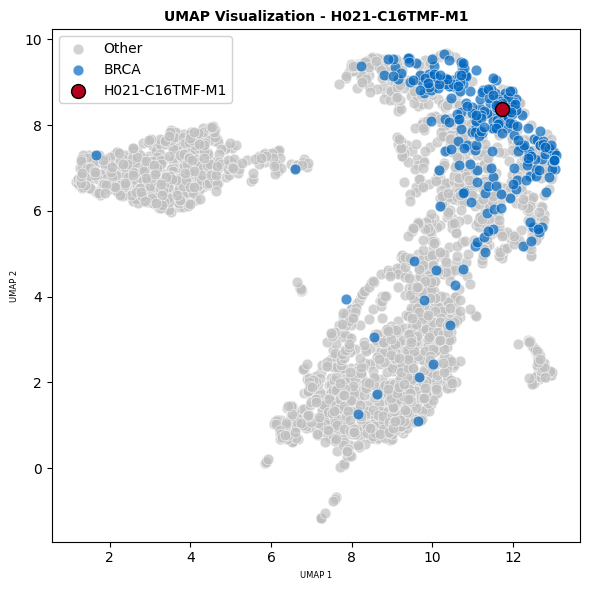

In [104]:

fig = generate_umap_visualization(
    data_clean=data_clean,
    signatures=signatures,
    sample_name='H021-C16TMF-M1',
    signature_key='BRCA',
    min_dist = 0.1
)

plt.show()

/home/lestrada/miniconda3/envs/portal/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



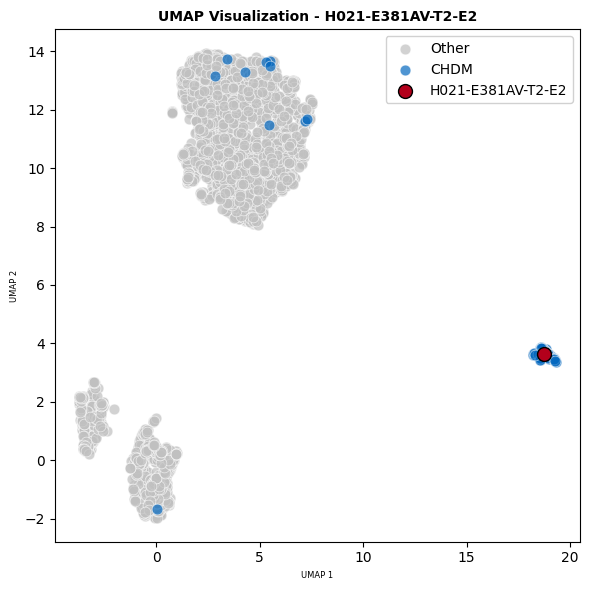

In [107]:

fig = generate_umap_visualization(
    data_clean=data_clean,
    signatures=signatures,
    sample_name='H021-E381AV-T2-E2',
    signature_key='CHDM'
)

plt.show()

/home/lestrada/miniconda3/envs/portal/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



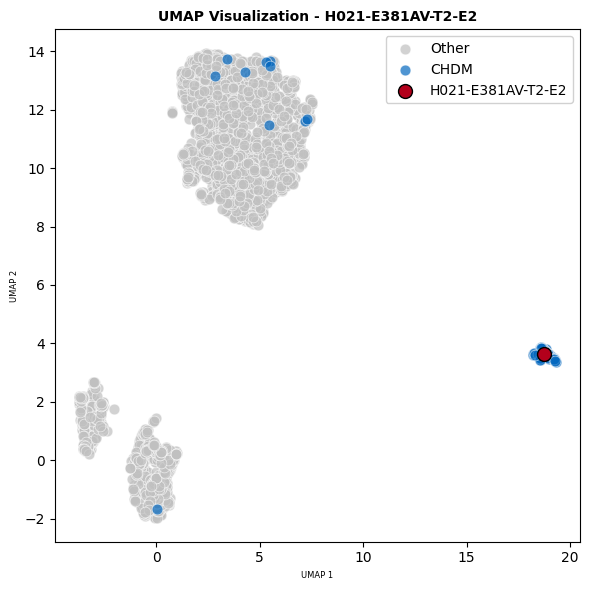

In [109]:

fig = generate_umap_visualization(
    data_clean=data_clean,
    signatures=signatures,
    sample_name='H021-E381AV-T2-E2',
    signature_key='CHDM'
)

plt.show()

In [ ]:

def generate_umap_visualization_plotly(
    data_clean: pd.DataFrame,
    signatures: Dict[str, List],
    sample_name: str,
    signature_key: str,
    n_neighbors: int = 10,
    min_dist: float = 0.1,
    random_state: int = 93
):
    """
    Generate interactive UMAP visualization with Plotly.
    
    Parameters:
    -----------
    data_clean : pd.DataFrame
        DataFrame with numeric variables and 'code_oncotree' column
    signatures : Dict[str, List]
        Dictionary with signature keys and lists of values to filter
    sample_name : str
        Sample name to highlight in #B3001B (from index)
    signature_key : str
        Key from signatures dict to use for filtering and coloring
    n_neighbors : int
        UMAP n_neighbors parameter
    min_dist : float
        UMAP min_dist parameter
    random_state : int
        Random state for reproducibility
        
    Returns:
    --------
    fig : plotly.graph_objects.Figure
        The generated interactive figure
    """
    
    # Validate inputs
    if signature_key not in signatures:
        raise ValueError(f"signature_key '{signature_key}' not found in signatures dictionary")
    
    if 'code_oncotree' not in data_clean.columns:
        raise ValueError("'code_oncotree' column not found in data_clean")
    
    if sample_name not in data_clean.index:
        raise ValueError(f"sample_name '{sample_name}' not found in data_clean index")
    
    # Get signature values to filter by
    signature_values = signatures[signature_key]
    
    # Prepare data for UMAP
    X = data_clean[signature_values].values
    
    # Generate UMAP embedding
    reducer = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state,
        n_components=2
    )
    embedding = reducer.fit_transform(X)
    
    # Create color array and organize data by groups
    groups = {'Other': [], signature_key: [], sample_name: []}
    colors_map = {'Other': 'silver', signature_key: '#0468BF', sample_name: '#B3001B'}
    
    for i, idx in enumerate(data_clean.index):
        if idx == sample_name:
            groups[sample_name].append(i)
        elif data_clean.loc[idx, 'code_oncotree'] == signature_key:
            groups[signature_key].append(i)
        else:
            groups['Other'].append(i)
    
    # Create figure
    fig = go.Figure()
    
    # Plot in order: Other (silver), signature (cyan), sample (red)
    for group_name in ['Other', signature_key, sample_name]:
        indices = groups[group_name]
        if len(indices) > 0:
            indices = np.array(indices)
            
            # Determine marker properties
            if group_name == sample_name:
                marker_size = 12
                marker_opacity = 1.0
                marker_line = dict(color='black', width=1)
            else:
                marker_size = 8
                marker_opacity = 0.7
                marker_line = dict(color='white', width=0.5)
            
            fig.add_trace(go.Scatter(
                x=embedding[indices, 0],
                y=embedding[indices, 1],
                mode='markers',
                name=group_name,
                marker=dict(
                    color=colors_map[group_name],
                    size=marker_size,
                    opacity=marker_opacity,
                    line=marker_line
                ),
                text=[data_clean.index[i] for i in indices],
                hovertemplate='<b>%{text}</b><br>UMAP1: %{x:.2f}<br>UMAP2: %{y:.2f}<extra></extra>'
            ))
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=f'UMAP Visualization - {sample_name}',
            font=dict(size=12, family='Arial, sans-serif'),
            x=0.5,
            xanchor='center'
        ),
        xaxis_title='UMAP 1',
        yaxis_title='UMAP 2',
        width=600,
        height=600,
        hovermode='closest',
        plot_bgcolor='white',
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor="rgba(255, 255, 255, 0.9)",
            bordercolor="gray",
            borderwidth=1
        ),
        font=dict(size=10)
    )
    
    # Update axes
    fig.update_xaxes(
        showgrid=True,
        gridwidth=1,
        gridcolor='lightgray',
        zeroline=False
    )
    fig.update_yaxes(
        showgrid=False
    )
    
    return fig


In [115]:
fig = generate_umap_visualization_plotly(
    data_clean=data_clean,
    signatures=signatures,
    sample_name='H021-E381AV-T2-E2',
    signature_key='CHDM'
)

# Display or save
fig.show()

/home/lestrada/miniconda3/envs/portal/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.

